In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings as warn

import folium
from folium.plugins import MarkerCluster

In [53]:
d1 = pd.read_csv(r"C:\Users\Administrator\PycharmProjects\DIC_PROJ\P1\datasets\CaliHousing\archive\housingTest.csv")

# let's see what data we could use to build our app 

In [54]:
d1.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [55]:
d1.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


* longitude and latitude: could be used to pin-point locations in the map for finding recommendations for the user according to the inputs
* housing_median_age: to compare against user's housing age preference
* total_bedrooms: user's preference
* population: user can decide whether to stay in a densely populated area or would prefer something private
* median_income: could be compared against user's income
* median_house_value: could be compared against user's housing budget
* ocean_proximity: user could decide how close or far away from the ocean would be a good idea

* locality finder: takes in user's preferences and suggests a locality.

* housing value predictor: predicts housing value based on user's preferences
### so why not have both housing value predictor and locality finder in the app

### what other things could we have in our app?
* locality finder
* housing value predictor
* a feature that takes in user preferences and suggests potential options user could get, call it "help me decide"

## let's try to bring this idea to reality

In [56]:
# before anything else it's important to check if we've got null values

d1.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

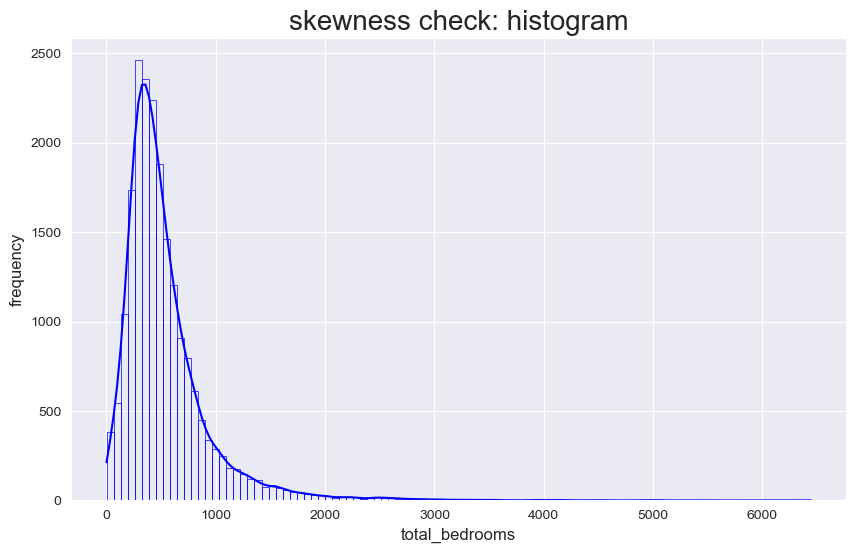

In [57]:
# fixing null values
feature = 'total_bedrooms'
# Prints the skewness of a Data Feature
def skewnessOfFeatureData(data, feature):
    print(f"skewness: {data[feature].skew()}")
    
# Create a Histogram of a given Feature and Bin Size of the Data using Seaborn
def createHistogram(my_data, feature, bin_size):
        try:
                warn.filterwarnings("ignore")
                plt.figure(figsize=(10, 6))
                
                sns.histplot(data=my_data[feature], bins=bin_size, kde=True, legend=True, fill=False, color='blue')
                
                plt.title("skewness check: histogram", fontsize=20)
                plt.xlabel(feature, fontsize=12)
                plt.ylabel("frequency", fontsize=12)
                # plt.legend()
                plt.show()
                warn.resetwarnings()
        except ValueError as e:
                pass

createHistogram(d1, "total_bedrooms", 100)

In [58]:
d1[feature] = d1[feature].fillna(d1[feature].median())

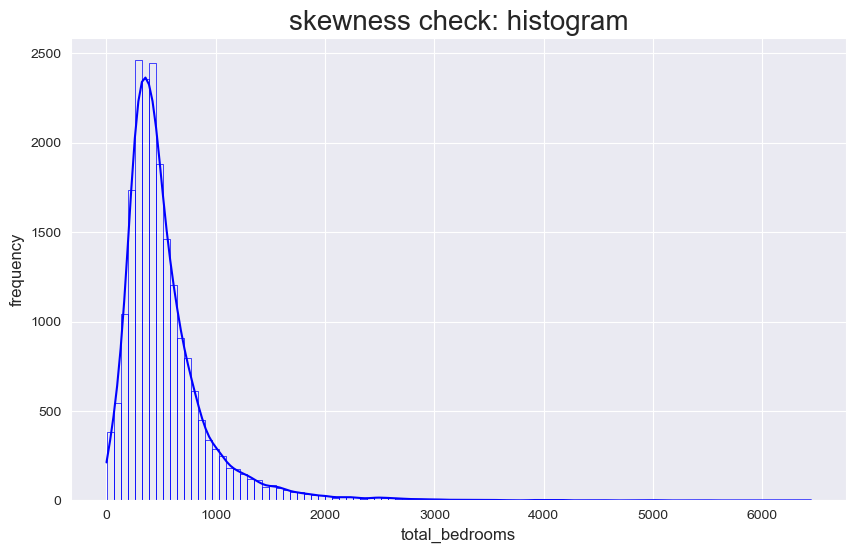

In [59]:
createHistogram(d1, "total_bedrooms", 100)

In [60]:
d1.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

### converting categorical "ocean_proximity" to numerical

In [61]:
# Assigning Categorical Ocean Proximity data to Numerical Values

feature = "ocean_proximity"

category_mapping = {
        "NEAR BAY": 0,
        "<1H OCEAN": 1,
        "INLAND": 2,
        "NEAR OCEAN": 3,
        "ISLAND": 4
    }

d1["ocean_proximity_encoded"] = d1[feature].map(category_mapping)

pd.DataFrame(d1["ocean_proximity_encoded"].unique(), d1["ocean_proximity"].unique())

,0
NEAR BAY,0
<1H OCEAN,1
INLAND,2
NEAR OCEAN,3
ISLAND,4


In [62]:
d1.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_encoded
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0


In [63]:
d1["avg_bed"] = d1["total_bedrooms"] / d1["households"]
d1["avg_population"] = d1["population"] / d1["households"]
d1["bed_to_room"] = d1["total_bedrooms"] / d1["total_rooms"]
d1["inc_per_cap"] = d1["median_income"] / d1["population"]

d1.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_encoded,avg_bed,avg_population,bed_to_room,inc_per_cap
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0,1.023810,2.555556,0.146591,0.025855
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0,0.971880,2.109842,0.155797,0.003457
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0,1.073446,2.802260,0.129516,0.014632
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0,1.073059,2.547945,0.184458,0.010113
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0,1.081081,2.181467,0.172096,0.006807


In [64]:
d1.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'ocean_proximity_encoded',
       'avg_bed', 'avg_population', 'bed_to_room', 'inc_per_cap'],
      dtype='object')

In [65]:
import pandas as pd

ranges = [-float("inf"), 119600, 179700, 264725, float("inf")]
labels = ["low", "medium", "high", "very high"]

d1["price_category"] = pd.cut(d1["median_house_value"], bins=ranges, labels=labels)

print(d1[["median_house_value", "price_category"]])

       median_house_value price_category
0                452600.0      very high
1                358500.0      very high
2                352100.0      very high
3                341300.0      very high
4                342200.0      very high
...                   ...            ...
20635             78100.0            low
20636             77100.0            low
20637             92300.0            low
20638             84700.0            low
20639             89400.0            low

[20640 rows x 2 columns]


In [66]:
feature = "price_category"

category_mapping = {
        "low": 0,
        "medium": 1,
        "high": 2,
        "very high": 3
    }

d1["price_category_encoded"] = d1[feature].map(category_mapping)

pd.DataFrame(d1["price_category_encoded"].unique(), d1["price_category"].unique())

,0
very high,3
high,2
medium,1
low,0


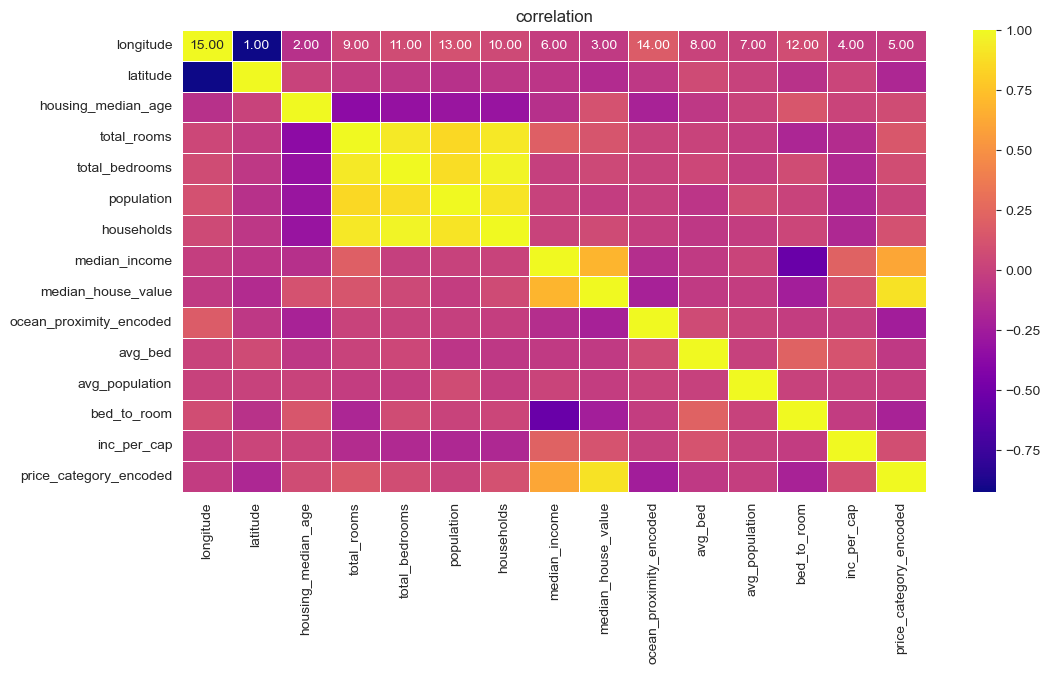

In [67]:
# Correlation Matrix with new engineered features
d1_correlation_matrix = d1.drop(['ocean_proximity', 'price_category'], axis=1).corr()

plt.figure(figsize=(12, 6))
sns.heatmap(d1_correlation_matrix, annot=d1_correlation_matrix.rank(axis="columns"), cmap='plasma', fmt='.2f', linewidths=0.5)
plt.title("correlation")
plt.show()

# building housing value predictor

#### predicts housing value based on user's preferences

In [68]:
d2 = d1.drop(['ocean_proximity', 'price_category'], axis=1).copy()
d2.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_encoded', 'avg_bed',
       'avg_population', 'bed_to_room', 'inc_per_cap',
       'price_category_encoded'],
      dtype='object')

In [69]:
from sklearn.preprocessing import StandardScaler

# Shifts and Scales Data to Normalize the Data to a mean=0 and std_dev = 1
warn.filterwarnings("ignore")
scaler = StandardScaler()

standardized_data = scaler.fit_transform(d2)
d2 = pd.DataFrame(standardized_data, columns = d2.columns)

print(d2.describe())
warn.resetwarnings()

          longitude      latitude  housing_median_age   total_rooms  \
count  2.064000e+04  2.064000e+04        2.064000e+04  2.064000e+04   
mean  -8.526513e-15 -1.079584e-15        5.508083e-18  3.201573e-17   
std    1.000024e+00  1.000024e+00        1.000024e+00  1.000024e+00   
min   -2.385992e+00 -1.447568e+00       -2.196180e+00 -1.207283e+00   
25%   -1.113209e+00 -7.967887e-01       -8.453931e-01 -5.445698e-01   
50%    5.389137e-01 -6.422871e-01        2.864572e-02 -2.332104e-01   
75%    7.784964e-01  9.729566e-01        6.643103e-01  2.348028e-01   
max    2.625280e+00  2.958068e+00        1.856182e+00  1.681558e+01   

       total_bedrooms    population    households  median_income  \
count    2.064000e+04  2.064000e+04  2.064000e+04   2.064000e+04   
mean    -9.363741e-17 -1.101617e-17  6.885104e-17   6.609700e-17   
std      1.000024e+00  1.000024e+00  1.000024e+00   1.000024e+00   
min     -1.277688e+00 -1.256123e+00 -1.303984e+00  -1.774299e+00   
25%     -5.718868e-0

In [70]:
d2.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_encoded,avg_bed,avg_population,bed_to_room,inc_per_cap,price_category_encoded
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,2.129631,-1.714727,-0.148514,-0.049597,-1.029988,1.076830,1.341753
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.314156,-1.714727,-0.248542,-0.092512,-0.888897,-0.097032,1.341753
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.258693,-1.714727,-0.052902,-0.025843,-1.291686,0.488630,1.341753
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,1.165100,-1.714727,-0.053647,-0.050329,-0.449613,0.251796,1.341753
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,1.172900,-1.714727,-0.038196,-0.085616,-0.639087,0.078543,1.341753


In [71]:
hma_test = 0.982143 * 12.585558 + 28.639486
print(hma_test)

41.000303690794


In [72]:
d1.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_encoded,avg_bed,avg_population,bed_to_room,inc_per_cap
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909,1.464729,1.100910,3.070655,0.213794,0.005309
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874,0.854226,0.519159,10.386050,0.065248,0.019080
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000,0.121204,0.692308,0.037151,0.000072
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000,1.000000,1.005525,2.429741,0.175225,0.001761
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,1.000000,1.048860,2.818116,0.203159,0.003002
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000,2.000000,1.100015,3.282261,0.240126,0.005027
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,4.000000,34.066667,1243.333333,2.824675,1.153854


In [73]:
d1.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_encoded,avg_bed,avg_population,bed_to_room,inc_per_cap,price_category,price_category_encoded
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0,1.023810,2.555556,0.146591,0.025855,very high,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0,0.971880,2.109842,0.155797,0.003457,very high,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0,1.073446,2.802260,0.129516,0.014632,very high,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0,1.073059,2.547945,0.184458,0.010113,very high,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0,1.081081,2.181467,0.172096,0.006807,very high,3


In [74]:
d1["median_house_value"].describe()

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

In [75]:
d1.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'ocean_proximity_encoded',
       'avg_bed', 'avg_population', 'bed_to_room', 'inc_per_cap',
       'price_category', 'price_category_encoded'],
      dtype='object')

In [76]:
features = d2[['population', 'avg_bed', 'ocean_proximity_encoded', 'housing_median_age']]
target = d2['median_house_value']

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [78]:
from sklearn.ensemble import RandomForestRegressor

rf1 = RandomForestRegressor(n_jobs=-1, random_state=42, n_estimators=97, max_depth=19)
rf1.fit(X_train, y_train)

C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\sklearn\utils\validation.py:595: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\sklearn\utils\validation.py:604: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


RandomForestRegressor(max_depth=19, n_estimators=97, n_jobs=-1, random_state=42)

In [79]:
from sklearn.metrics import mean_squared_error

predictions = rf1.predict(X_test)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
print(f"RMSE: {rmse}")

RMSE: 0.8716062327393699


C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\sklearn\utils\validation.py:595: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\sklearn\utils\validation.py:604: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


In [80]:
scale = d2['median_house_value'].describe()['max'] - d2['median_house_value'].describe()['min']
# RMSE Relative to Scale
rel_rmse = rmse / scale

rel_rmse

0.20737461181110164

#### The RMSE is approximately 20.7% of the range of the data
RMSE that is ~20% of the range of the data can generally be considered reasonable

In [81]:
d2.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_encoded,avg_bed,avg_population,bed_to_room,inc_per_cap,price_category_encoded
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04
mean,-8.526513e-15,-1.079584e-15,5.508083e-18,3.201573e-17,-9.363741e-17,-1.101617e-17,6.885104e-17,6.609700e-17,-9.363741e-17,5.508083e-17,1.666195e-16,3.442552e-18,1.542263e-16,-1.239319e-17,1.652425e-17
std,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00
min,-2.385992e+00,-1.447568e+00,-2.196180e+00,-1.207283e+00,-1.277688e+00,-1.256123e+00,-1.303984e+00,-1.774299e+00,-1.662641e+00,-1.714727e+00,-1.887148e+00,-2.290000e-01,-2.707317e+00,-2.744626e-01,-1.341320e+00
25%,-1.113209e+00,-7.967887e-01,-8.453931e-01,-5.445698e-01,-5.718868e-01,-5.638089e-01,-5.742294e-01,-6.881186e-01,-7.561633e-01,-5.440480e-01,-1.837349e-01,-6.171062e-02,-5.911329e-01,-1.859470e-01,-1.341320e+00
50%,5.389137e-01,-6.422871e-01,2.864572e-02,-2.332104e-01,-2.428309e-01,-2.291318e-01,-2.368162e-01,-1.767951e-01,-2.353337e-01,-5.440480e-01,-1.002612e-01,-2.431585e-02,-1.629966e-01,-1.208889e-01,-4.469623e-01
75%,7.784964e-01,9.729566e-01,6.643103e-01,2.348028e-01,2.537334e-01,2.644949e-01,2.758427e-01,4.593063e-01,5.014973e-01,6.266307e-01,-1.724890e-03,2.037453e-02,4.035794e-01,-1.476954e-02,6.709851e-01
max,2.625280e+00,2.958068e+00,1.856182e+00,1.681558e+01,1.408779e+01,3.025033e+01,1.460152e+01,5.858286e+00,2.540411e+00,2.967988e+00,6.349991e+01,1.194191e+02,4.001560e+01,6.019654e+01,1.341753e+00


In [82]:
d1.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_encoded,avg_bed,avg_population,bed_to_room,inc_per_cap,price_category,price_category_encoded
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0,1.023810,2.555556,0.146591,0.025855,very high,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0,0.971880,2.109842,0.155797,0.003457,very high,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0,1.073446,2.802260,0.129516,0.014632,very high,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0,1.073059,2.547945,0.184458,0.010113,very high,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0,1.081081,2.181467,0.172096,0.006807,very high,3


In [83]:
d2.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_encoded,avg_bed,avg_population,bed_to_room,inc_per_cap,price_category_encoded
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,2.129631,-1.714727,-0.148514,-0.049597,-1.029988,1.076830,1.341753
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.314156,-1.714727,-0.248542,-0.092512,-0.888897,-0.097032,1.341753
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.258693,-1.714727,-0.052902,-0.025843,-1.291686,0.488630,1.341753
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,1.165100,-1.714727,-0.053647,-0.050329,-0.449613,0.251796,1.341753
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,1.172900,-1.714727,-0.038196,-0.085616,-0.639087,0.078543,1.341753


In [84]:
def convert_o_z(user_input):
    for key, value in user_input.items():
        o_mean = d1[key].describe()['mean']
        o_std = d1[key].describe()['std']
        user_input[key] = (value - o_mean) / o_std
    
    return user_input

In [85]:
def convert_z_o(val):
    o_mean = d1['median_house_value'].describe()['mean']
    o_std = d1['median_house_value'].describe()['std']
    o_val = (val * o_std) + o_mean
    return o_val

In [86]:
user_input = {'population': 322.0, 'avg_bed': 1.023810, 'ocean_proximity_encoded': 0, 'housing_median_age': 41.0}
user_input = convert_o_z(user_input)
print(user_input)

{'population': -0.9744049915469957, 'avg_bed': -0.14850974391734742, 'ocean_proximity_encoded': -1.7146851071160616, 'housing_median_age': 0.982118865674764}


In [87]:
# Example user input
user_input = {'population': 322.0, 'avg_bed': 3, 'ocean_proximity_encoded': 2, 'housing_median_age': 10.0}
user_input = convert_o_z(user_input)
# Encode and transform input
user_features = [user_input['population'], user_input['avg_bed'], user_input['ocean_proximity_encoded'], user_input['housing_median_age']]

# Predict
user_prediction = rf1.predict([user_features])
print(f"Predicted Median House Value: {user_prediction[0]}")
print(f"Converted (Z to O): {convert_z_o(user_prediction[0])}")

Predicted Median House Value: -0.5892712458562561
Converted (Z to O): 138856.49857624932


C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


#### exporting the model

In [88]:
import joblib
joblib.dump(rf1, r'C:\Users\Administrator\PycharmProjects\DIC_PROJ\P1\models\rf1_hvp_model.pkl')

['C:\\Users\\Administrator\\PycharmProjects\\DIC_PROJ\\P1\\models\\rf1_hvp_model.pkl']

# building locality finder

#### suggests latitude and longitude on a map based on user's preferences

In [89]:
d2.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_encoded', 'avg_bed',
       'avg_population', 'bed_to_room', 'inc_per_cap',
       'price_category_encoded'],
      dtype='object')

In [90]:
features = d2[['population', 'avg_bed', 'ocean_proximity_encoded', 'housing_median_age', 'median_income']]
target = d2[['median_house_value', 'latitude', 'longitude']]

In [91]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [92]:
rf2 = RandomForestRegressor(n_jobs=-1, random_state=42, n_estimators=97, max_depth=19)
rf2.fit(X_train, y_train)

C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\sklearn\utils\validation.py:595: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\sklearn\utils\validation.py:604: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version.

RandomForestRegressor(max_depth=19, n_estimators=97, n_jobs=-1, random_state=42)

In [93]:
# Predict on test data
predictions = rf2.predict(X_test)
mse = mean_squared_error(y_test, predictions, multioutput='raw_values')
rmse = np.sqrt(mse)

target_names = y_test.columns
for name, error in zip(target_names, rmse):
    print(f"RMSE for {name}: {error}")

RMSE for median_house_value: 0.6063173128174708
RMSE for latitude: 0.8102542901743537
RMSE for longitude: 0.8516793652667637


C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\sklearn\utils\validation.py:595: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\sklearn\utils\validation.py:604: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version.

In [94]:
target_names = y_test.columns
rel_rmse = []

for name in target_names:
    # Calculate the range (scale) of each target feature
    scale = d2[name].max() - d2[name].min()
    
    # Calculate the relative RMSE for each target feature
    index = list(target_names).index(name)
    relative_rmse = rmse[index] / scale
    rel_rmse.append(relative_rmse)
    print(f"Relative RMSE for {name}: {relative_rmse}")

Relative RMSE for median_house_value: 0.14425644592363862
Relative RMSE for latitude: 0.18391314220250982
Relative RMSE for longitude: 0.1699527180939221


#### On average, the RMSE is ~18-19% of the range of the data
This RMSE range of the data can generally be considered reasonable

In [95]:
d1.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_encoded,avg_bed,avg_population,bed_to_room,inc_per_cap,price_category,price_category_encoded
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0,1.023810,2.555556,0.146591,0.025855,very high,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0,0.971880,2.109842,0.155797,0.003457,very high,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0,1.073446,2.802260,0.129516,0.014632,very high,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0,1.073059,2.547945,0.184458,0.010113,very high,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0,1.081081,2.181467,0.172096,0.006807,very high,3


In [96]:
d2.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_encoded,avg_bed,avg_population,bed_to_room,inc_per_cap,price_category_encoded
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,2.129631,-1.714727,-0.148514,-0.049597,-1.029988,1.076830,1.341753
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.314156,-1.714727,-0.248542,-0.092512,-0.888897,-0.097032,1.341753
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.258693,-1.714727,-0.052902,-0.025843,-1.291686,0.488630,1.341753
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,1.165100,-1.714727,-0.053647,-0.050329,-0.449613,0.251796,1.341753
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,1.172900,-1.714727,-0.038196,-0.085616,-0.639087,0.078543,1.341753


In [97]:
# Example user input
user_input = {'population': 322.0, 'avg_bed': 1.023810, 'ocean_proximity_encoded': 0, 'housing_median_age': 41.0, 'median_income': 8.3252}
user_input = convert_o_z(user_input)
# Encode and transform input
user_features = [user_input['population'], user_input['avg_bed'], user_input['ocean_proximity_encoded'], user_input['housing_median_age'], user_input['median_income']]

# Predict
user_prediction = rf2.predict([user_features])
print(f"Predicted results: {user_prediction[0]}")

Predicted results: [ 2.02399956  0.94071444 -1.30097479]


C:\ProgramData\anaconda3\envs\DIC_PROJ\Lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [98]:
def convert_z_o_lf(key, val):
    o_mean = d1[key].describe()['mean']
    o_std = d1[key].describe()['std']
    o_val = (val * o_std) + o_mean
    return o_val

In [99]:
key = ['median_house_value', 'latitude', 'longitude']
res_obj = {}
for idx, val in enumerate(user_prediction[0]):
    print(f"{key[idx]}: {convert_z_o_lf(key[idx], val)}")
    res_obj[key[idx]] = convert_z_o_lf(key[idx], val)

print(res_obj)

median_house_value: 440416.4930821946
latitude: 37.64118269662632
longitude: -122.17624871080453
{'median_house_value': 440416.4930821946, 'latitude': 37.64118269662632, 'longitude': -122.17624871080453}


In [100]:
import folium

def createSinglePointMap(data):
    # Extract latitude and longitude from the data dictionary
    latitude = data['latitude']
    longitude = data['longitude']

    # Calculate the map center directly from the latitude and longitude
    map_center = [latitude, longitude]

    # Initialize the map
    m = folium.Map(location=map_center, zoom_start=12)  # Adjust zoom_start as needed for better visibility

    # Add a marker for the location
    marker = folium.Marker(
        location=[latitude, longitude],
        popup=f"Median House Value: {data['median_house_value']:.2f}",  # Displaying the median house value in the popup
        tooltip="Click for more info"
    )
    marker.add_to(m)

    return m

print(res_obj)
map_object = createSinglePointMap(res_obj)
map_object

{'median_house_value': 440416.4930821946, 'latitude': 37.64118269662632, 'longitude': -122.17624871080453}


In [101]:
import joblib
joblib.dump(rf2, r'C:\Users\Administrator\PycharmProjects\DIC_PROJ\P1\models\rf2_lf_model.pkl')

['C:\\Users\\Administrator\\PycharmProjects\\DIC_PROJ\\P1\\models\\rf2_lf_model.pkl']